## Setup

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis, normaltest, probplot, stats
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score

## Classification

### EDA

In [ ]:
classification_train_df = pd.read_csv("/content/CS98XClassificationTrain.csv")
classification_test_df = pd.read_csv("/content/CS98XClassificationTest.csv")

In [ ]:
features = ['year','bpm','nrgy','dnce','dB','live','val','dur','acous','spch','pop']
x_train_numerical = classification_train_df[features]
x_test_numerical = classification_test_df[features]

In [ ]:
def feature_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generative descriptive statistics beyond what the usual pandas .describe method does.
    This function also provides the skew and kurtosis alongside mean, standard deviation,
    min and max values for the inputted dataframe. Including skewness and kurtosis allows
    for better understanding of the overall distribution of a given feature.
    Arguments:
    - df (pd.DataFrame): Dataframe for which to calculate the statistic for.
    Returns:
    - stats (pd.DataFrame): Dataframe which contains the descriptive statistics
    """
    stats = pd.DataFrame({
        "mean": df.mean(), # capture the mean, central tendency
        "std": df.std(), # standard deviation to check the spread of data points
        "skew": df.apply(skew), # skewness to detect asymmetry
        "kurtosis": df.apply(kurtosis), # kurtosis to determine outliers
        "min": df.min(), # min range of value
        "max": df.max() # max range of values
    })
    return stats

In [ ]:
def plot_feature_analysis(df, feature):
    """
    Highlighting importance of visualisation of data using histogram, boxplot and violin plot. This gives an
    graphical overview of the data distributions, skewness data density and outliers.
    Arguments:
    - df (pd.DataFrame): Dataframe for which to calculate the statistic for.
    - feature (str): Name of the feature to be analysed
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title("Histogram + KDE")
    sns.boxplot(x=df[feature], ax=axes[1])
    axes[1].set_title("Boxplot")
    sns.violinplot(x=df[feature], ax=axes[2])
    axes[2].set_title("Violin Plot")
    plt.suptitle(feature)
    plt.tight_layout()
    plt.show()

EDA for training data

In [ ]:
stats_train = feature_stats(x_train_numerical)

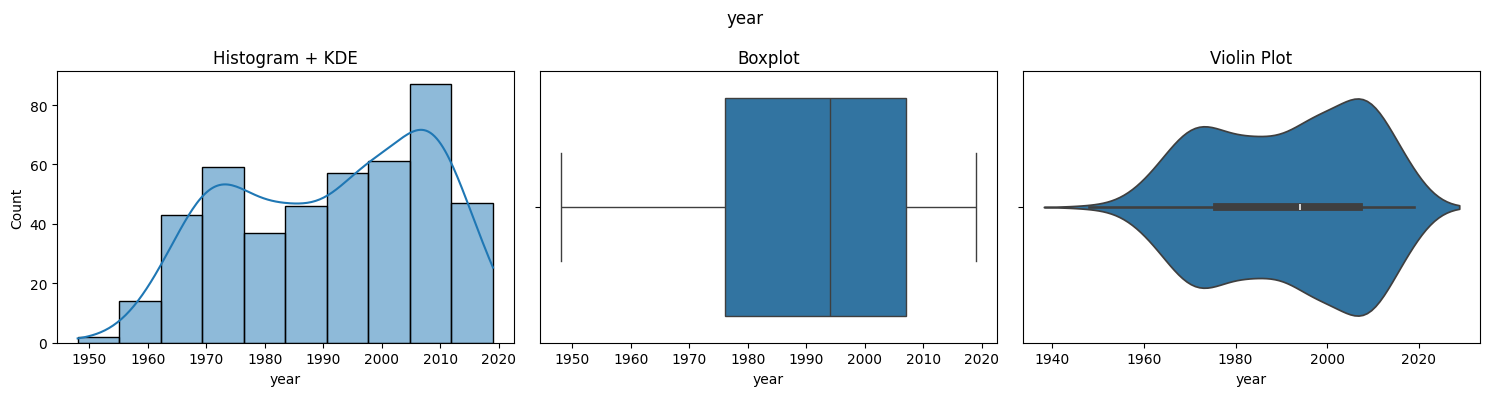

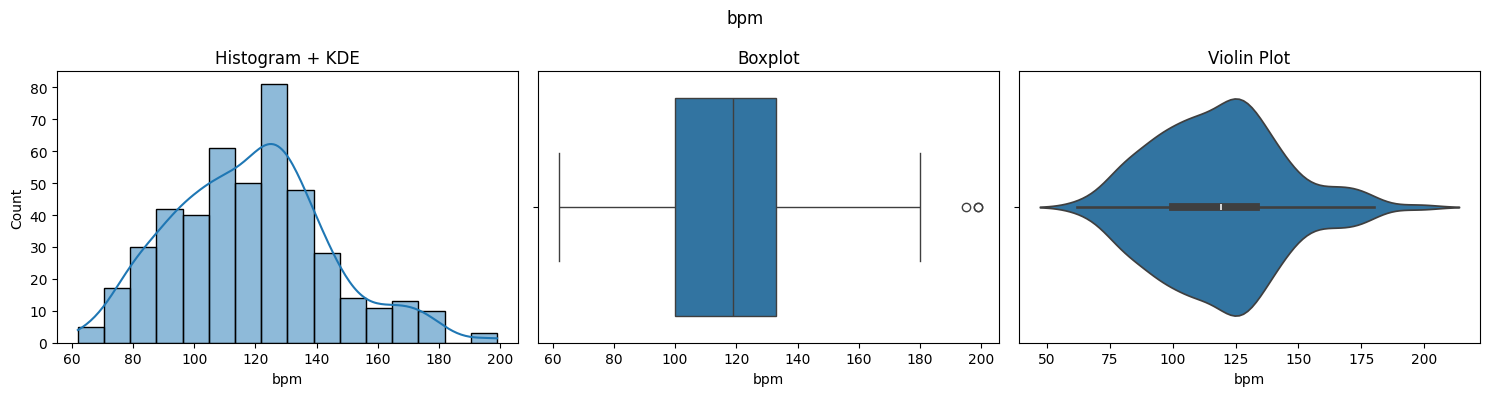

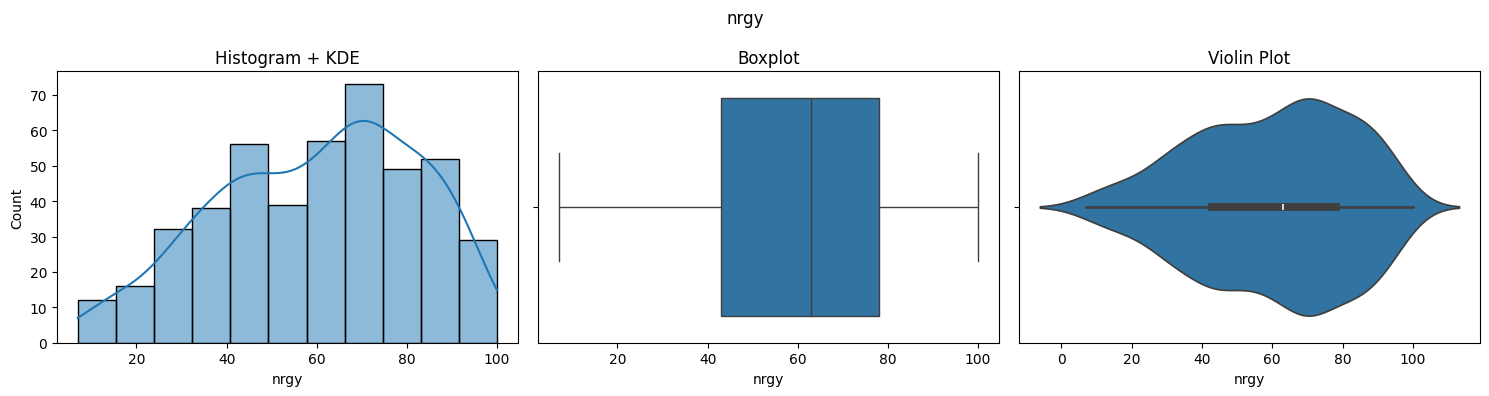

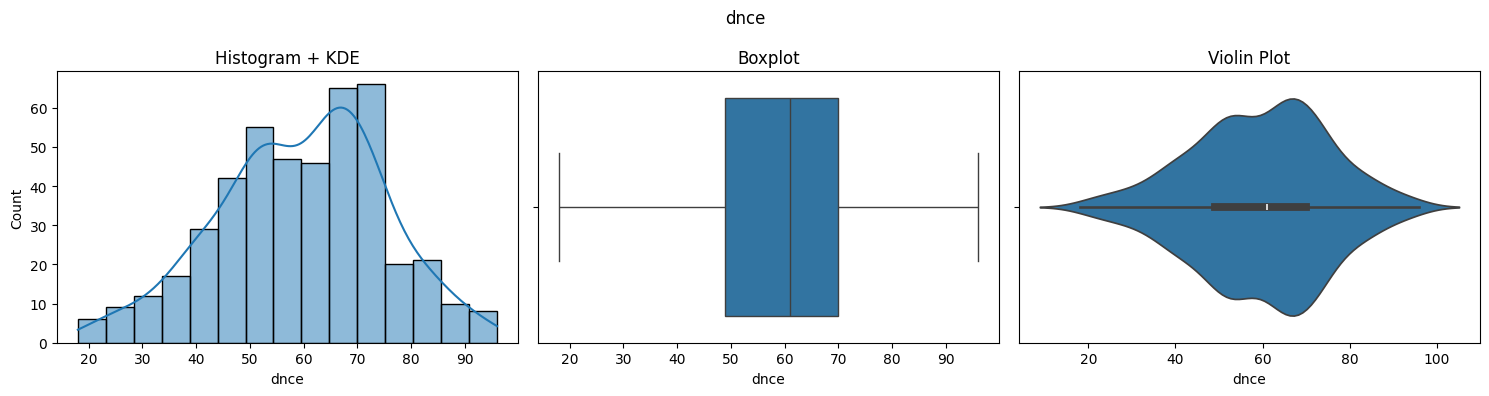

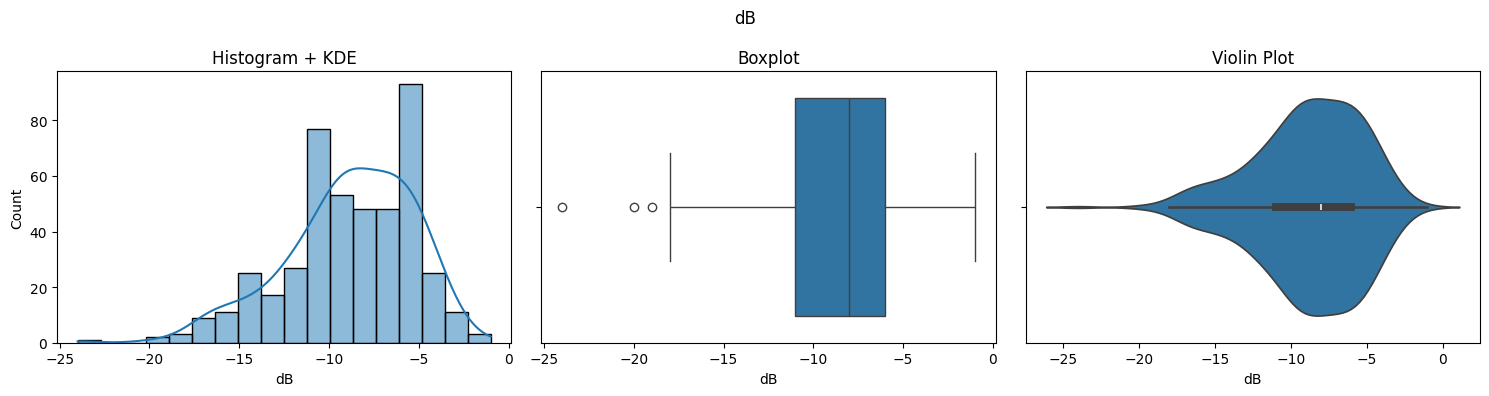

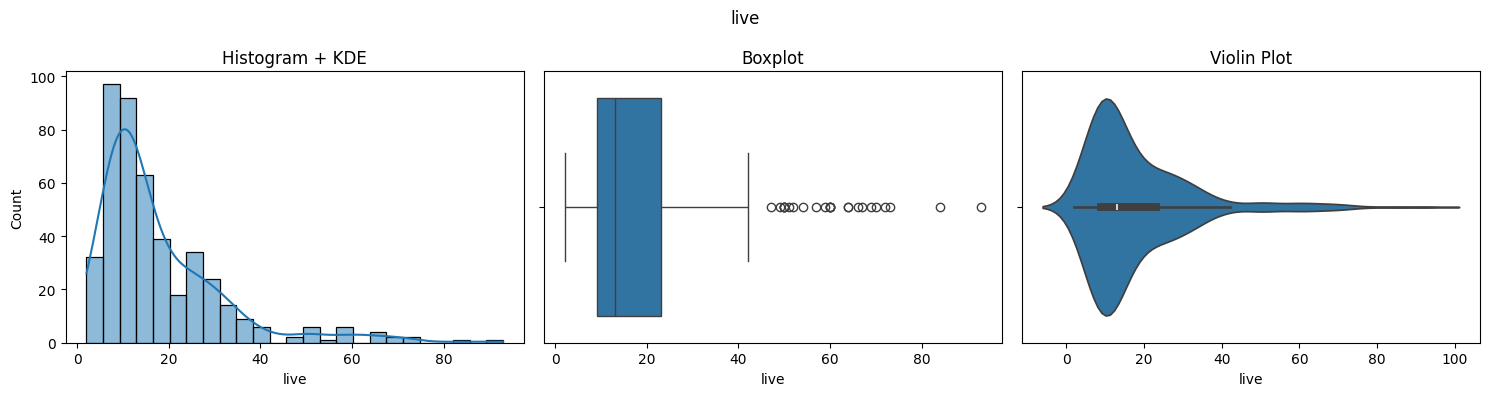

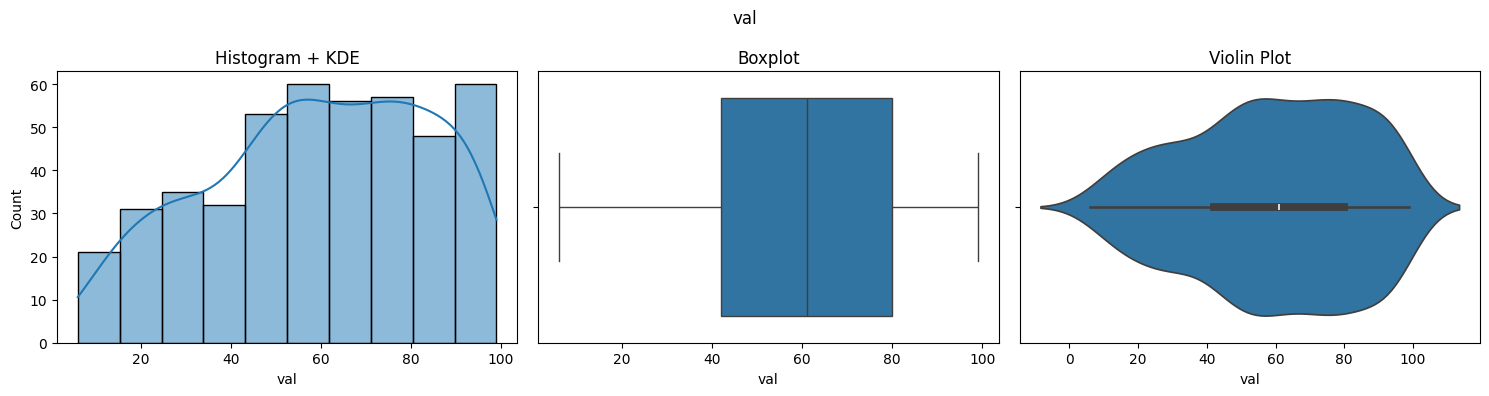

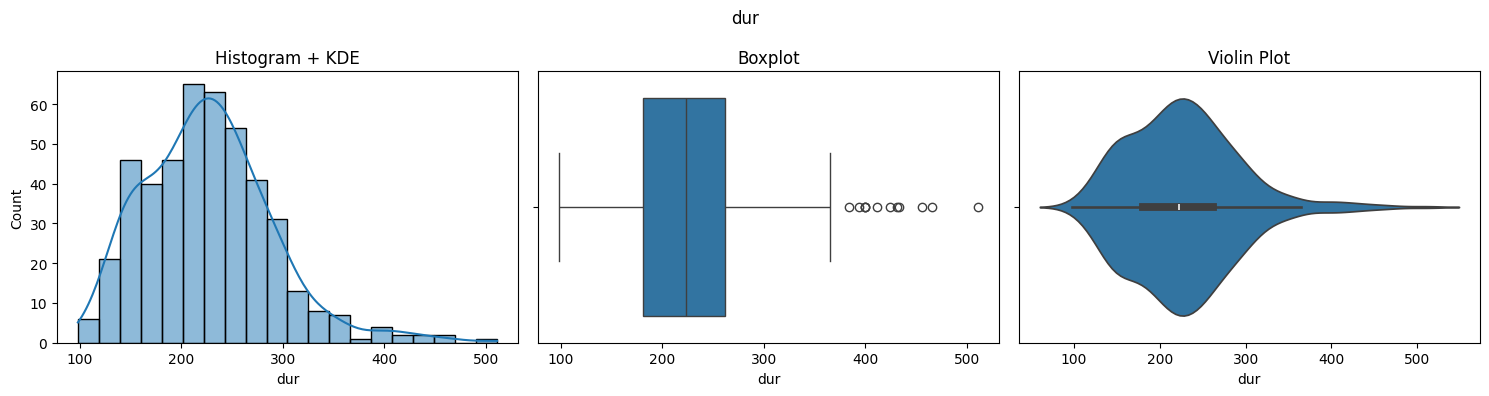

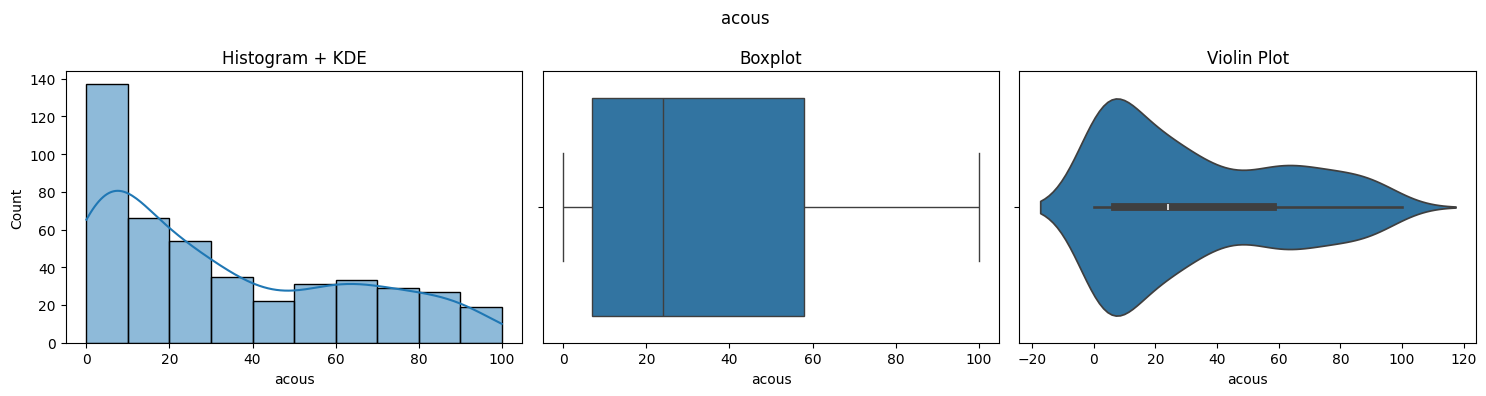

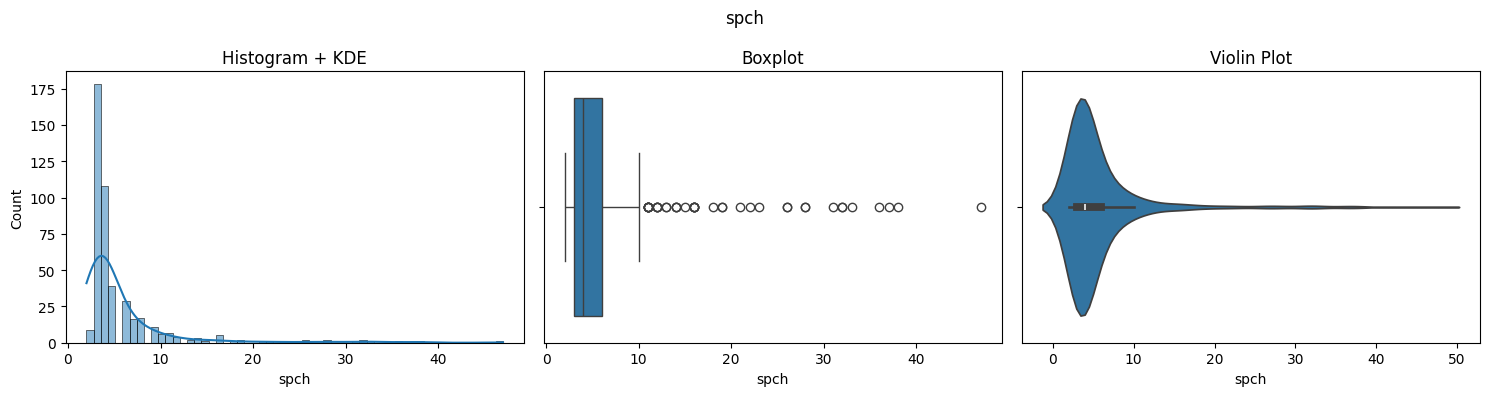

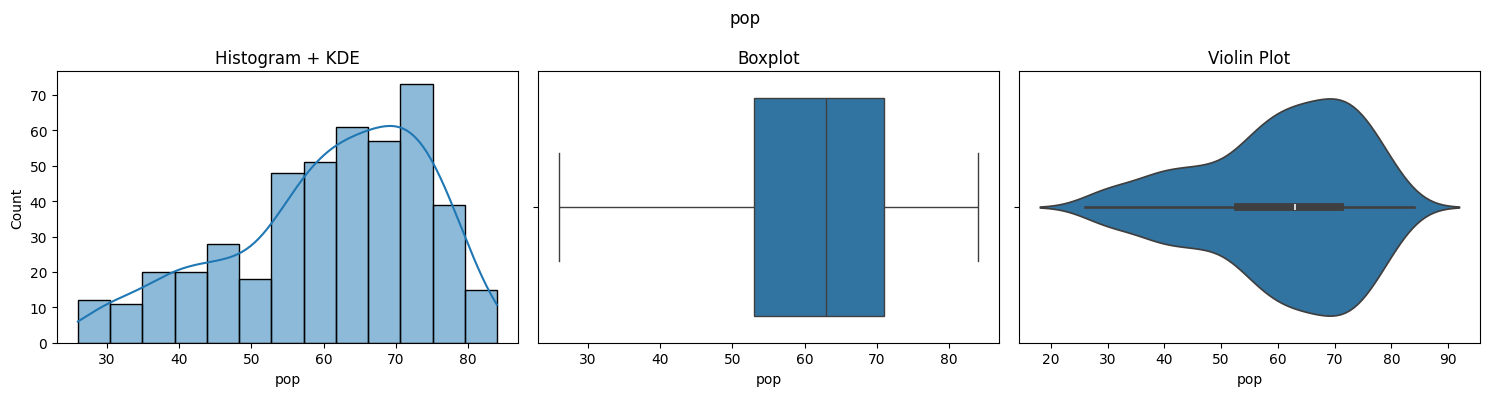

In [ ]:
for feature in x_train_numerical.columns:
    plot_feature_analysis(x_train_numerical, feature)

EDA for test data

In [ ]:
stats_test = feature_stats(x_test_numerical)

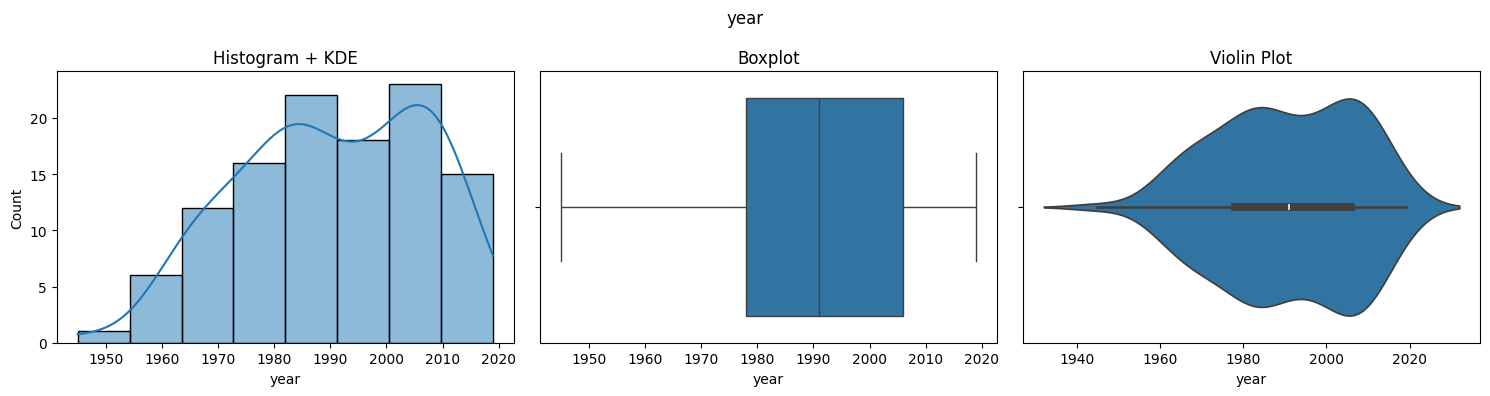

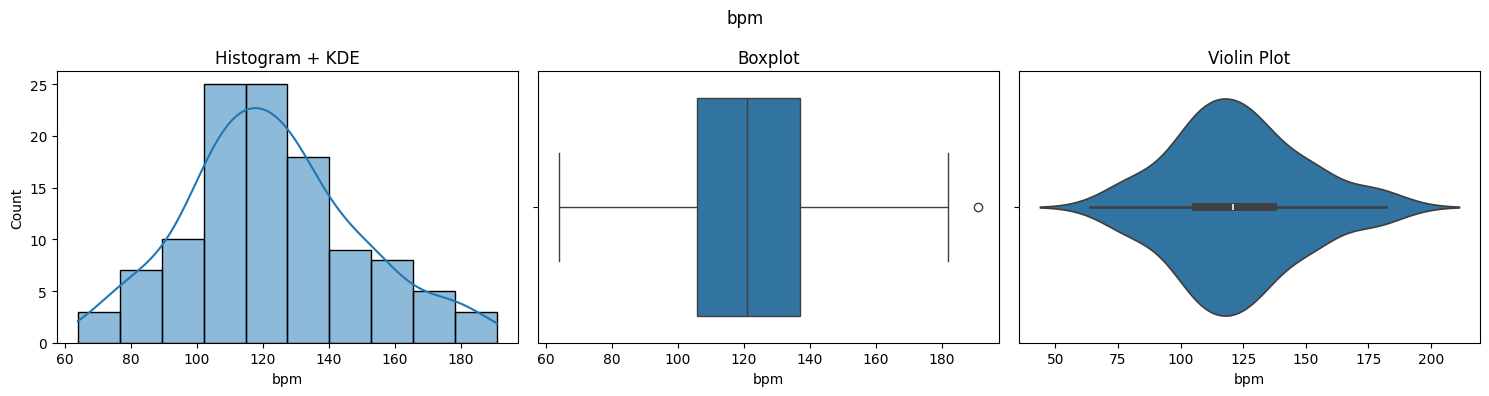

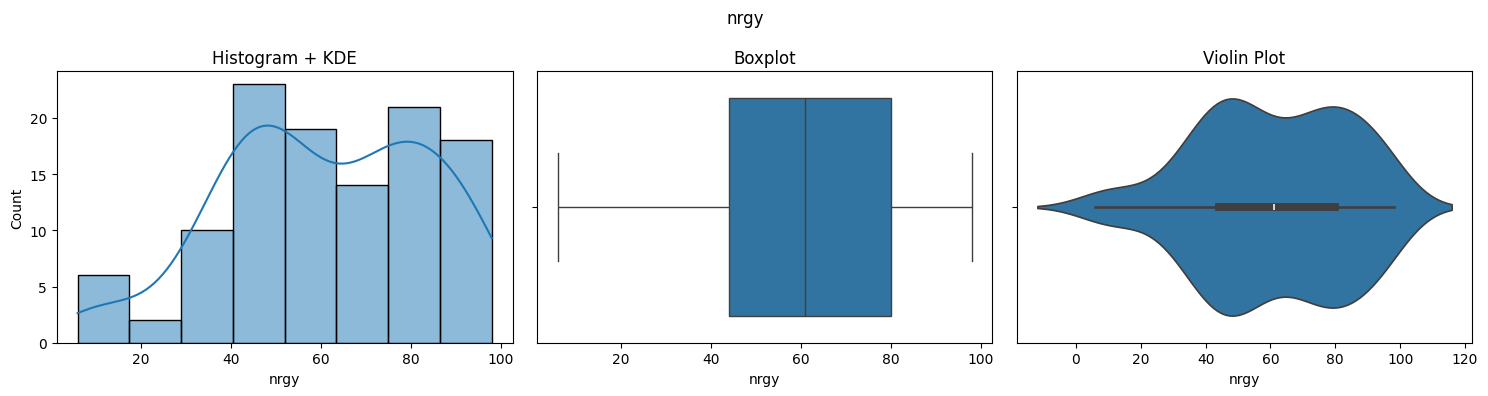

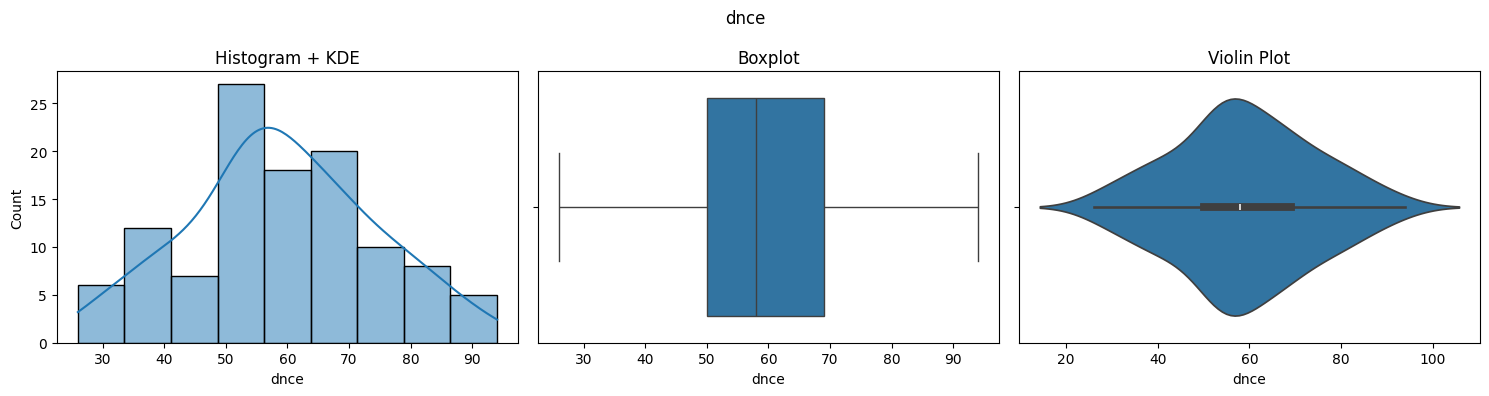

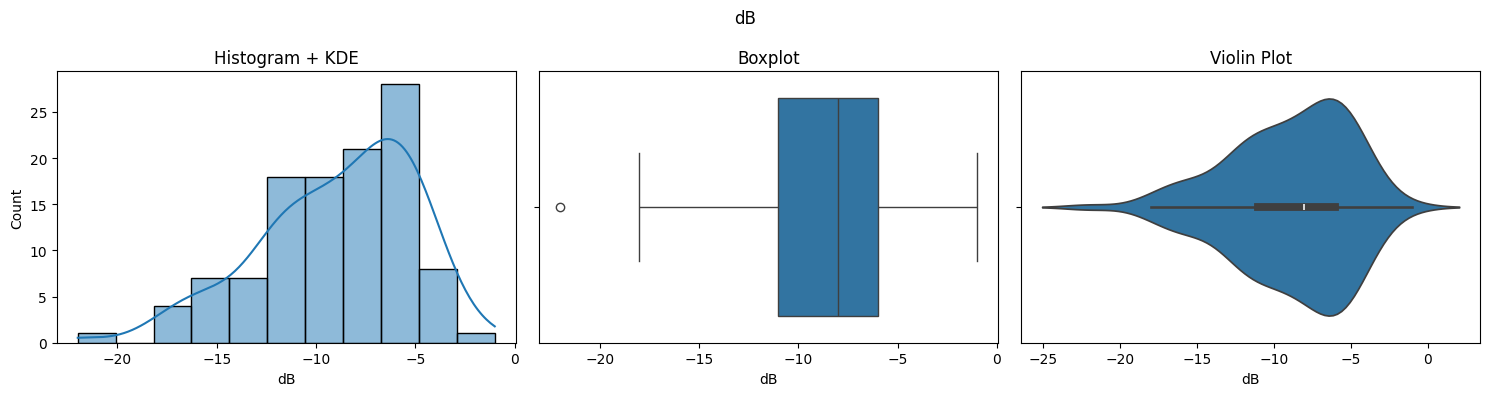

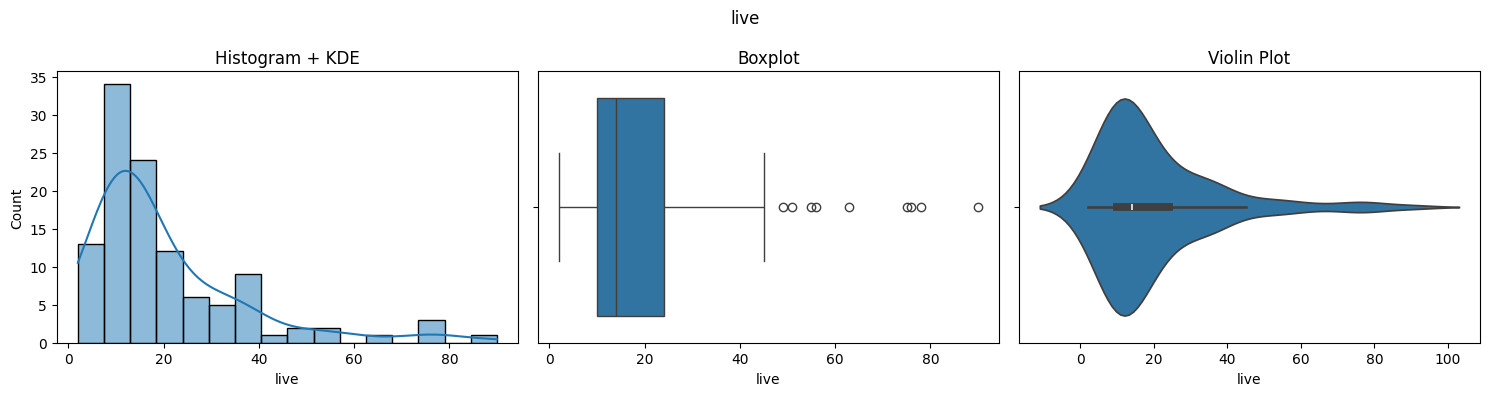

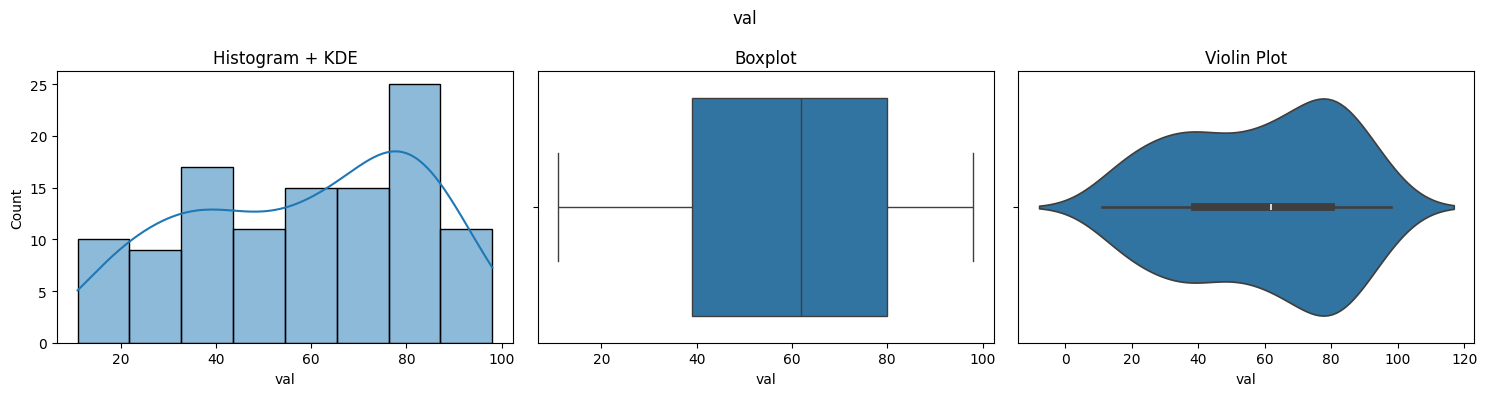

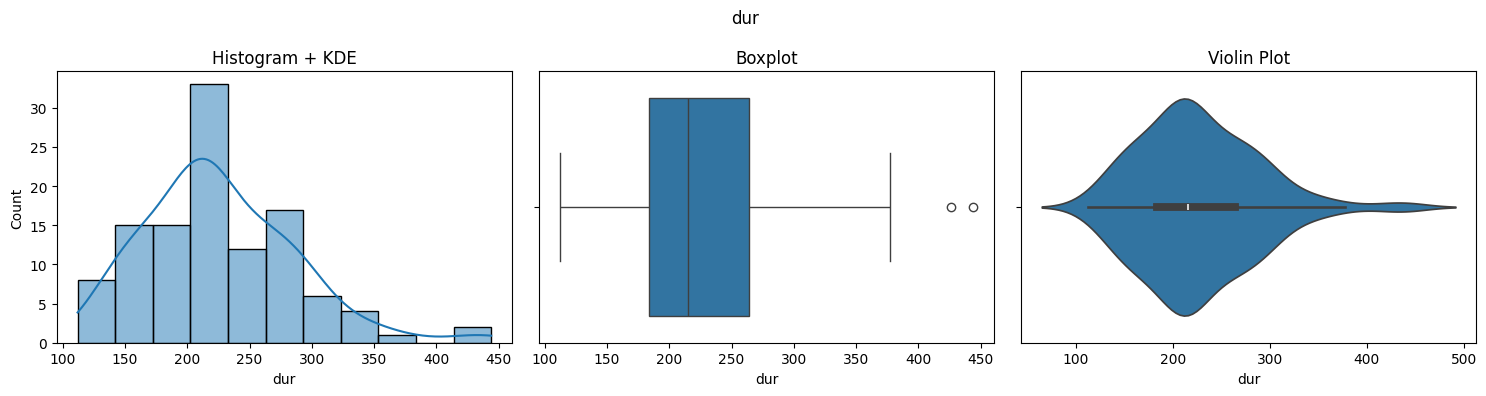

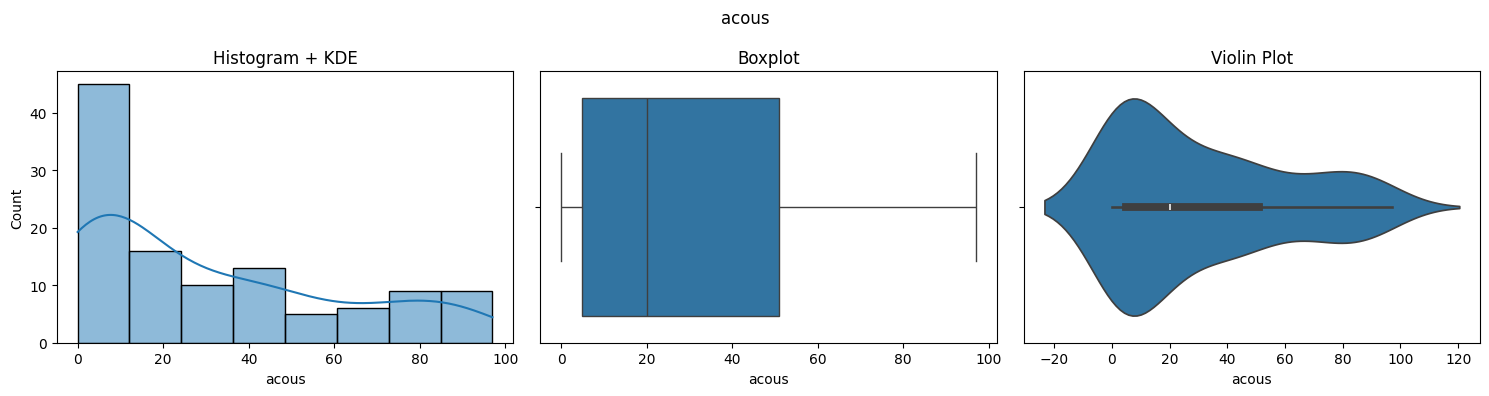

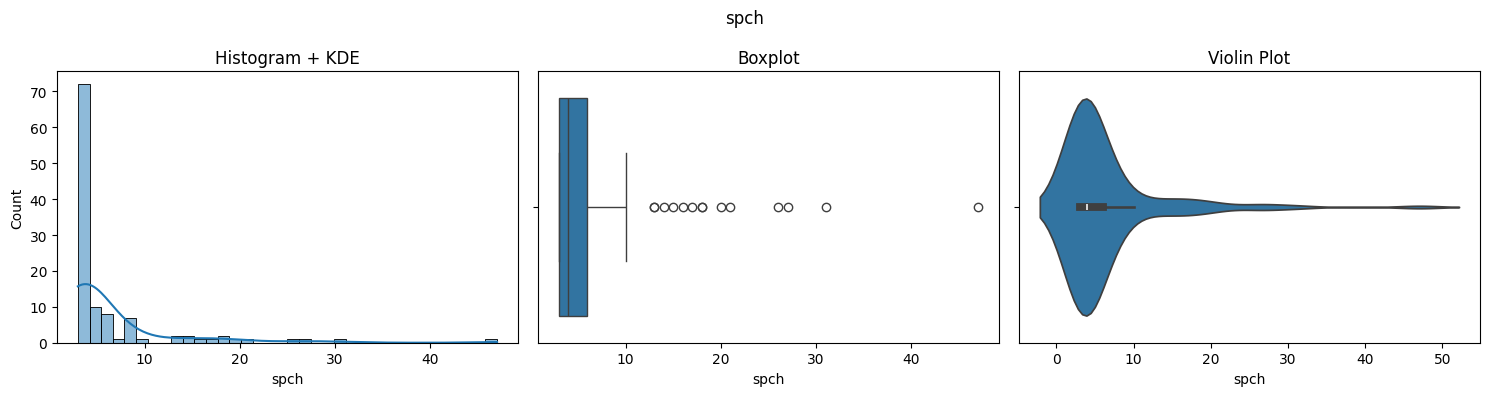

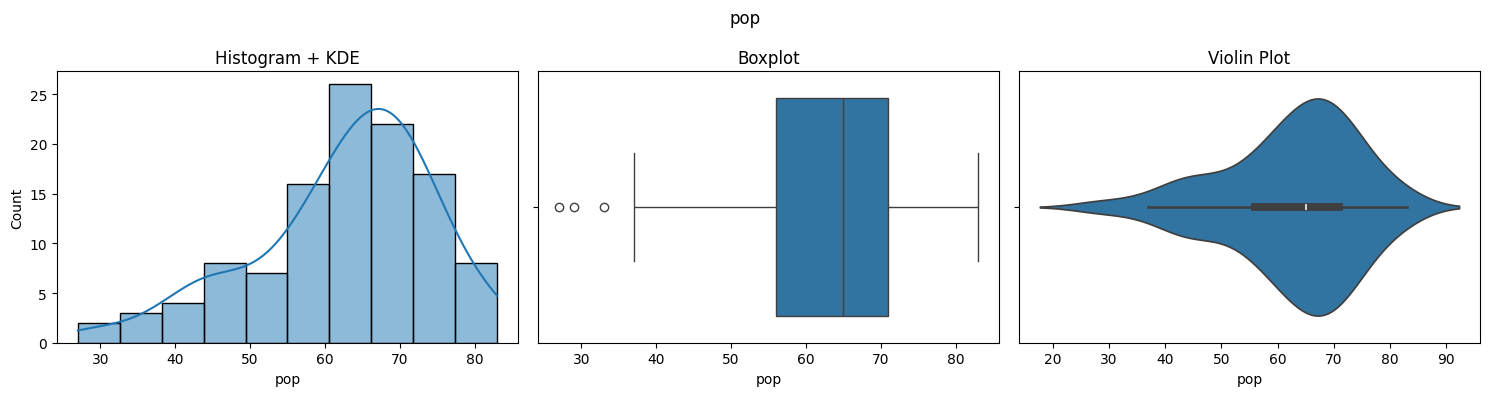

In [ ]:
for feature in x_test_numerical.columns:
    plot_feature_analysis(x_test_numerical, feature)

**Observations**
1. Both datasets have similar distributions.
2. Outliers: evident from Boxplot and QQ plots. For instance, "Live" and "spch" have comparitively many outliers.
3. Skewness and data distribution: evident from HIstogram+kde plots. For instancce, "Live", "acous" and "spch" are heavily right-skewed
4. Data density: evident from violin plots.

### Dealing with missing genres
We took the decision to drop the data, since 15 examples in the test dataset with 453 entreis, is under 4% overall and it shouldn't have that much of an impact in the overall accuracy of the model.

In [ ]:
classification_train_df.isnull().sum()

,0
Id,0
title,0
artist,0
year,0
bpm,0
nrgy,0
dnce,0
dB,0
live,0
val,0


In [ ]:
data_train_clean = classification_train_df.dropna(subset=["top genre"]).copy()

### Feature engineering

In [ ]:
def add_features(data, max_year):
    """
    Add additional features to the inputted dataframe by deriving new features from existing ones.
    Arguments:
    - data (pd.DataFrame): Dataframe for which to calculate the statistic for.
    - max_year (int): The year of the latest song in the dataset.
    Returns:
    - data (pd.DataFrame): Dataframe with the following additional features added
      - "song_age": The age of the song relative to the latest song in the dataset.
      - "loudness_pos": The positive values of "dB".
      - "log_dur": The log of duration.
      - "energy_dance": The product of "nrgy" and "dnce".
      - "beats": The ratio of "dur" and "bpm".
      - "title_ftr": The semantic embedding of the "title" column.
      """
    data["song_age"] = max_year - data["year"]
    #  Positive loudness: original 'dB' is negative so flipping sign
    data["loudness_pos"] = -data["dB"]
    #  Log transform of the duration as it is skewed
    data["log_dur"] = np.log1p(data["dur"])
    # Fixed the typo in the "artist column", as part of manual data analysis
    data["artist"] = (data["artist"].str.replace("√É¬©", "é", regex=False))
    #  interaction feature: energy * danceability
    data["energy_dance"] = data["nrgy"] * data["dnce"]
    #  deducing beats from dur as intuitively that should be more beneficial
    data['beats'] = (data['dur'] / 60) * data['bpm']
    # song titles carry semantic hints about the genre, Using below approach to capture this information as well as keeping it as a single feature
    titles = data['title'].tolist()
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(titles)  # shape: (num_titles, 384)
    # Reduce to 1 dimension (1 featrue)
    pca = PCA(n_components=1)
    title_feature = pca.fit_transform(embeddings)
    data['title_ftr'] = title_feature.flatten()
    return data
# using max year from training data so train and test are consistent
max_year = data_train_clean["year"].max()
train_feature_engineered = add_features(data_train_clean, max_year)
y_feature_engineered = train_feature_engineered["top genre"]
test_feature_engineered  = add_features(classification_test_df, max_year)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Unsupervised learning

Implementing Unsupervised learning (K means clustering) to extend Feature engineering and incorporate new features i.e. distance of each sample from its nearest cluster.

For training data

In [ ]:
target = "top genre"
drop_cols = ["Id", "title", "artist", target]
X = train_feature_engineered.drop(columns=drop_cols)
y = train_feature_engineered[target]
X_test = test_feature_engineered.drop(columns=["Id", "title", "artist"])
print("X shape:", X.shape, "y shape:", y.shape, "X_test shape:", X_test.shape)

X shape: (438, 17) y shape: (438,) X_test shape: (113, 17)


In [ ]:
X_kmeans = X.copy()
X_test_kmeans = X_test.copy()
scaler_for_kmeans = RobustScaler()
X_scaled_kmeans = scaler_for_kmeans.fit_transform(X_kmeans)
X_test_scaled_kmeans = scaler_for_kmeans.transform(X_test_kmeans)

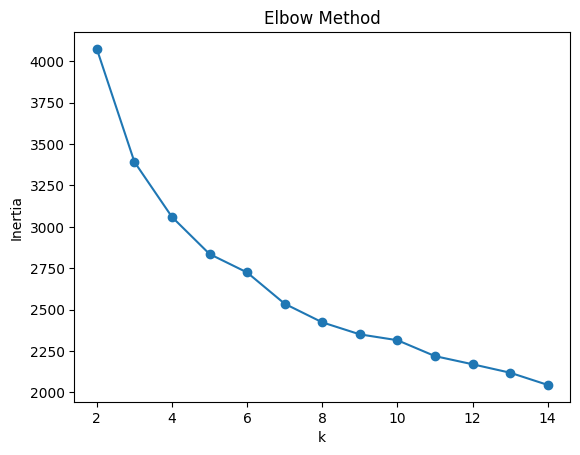

In [ ]:
inertias = []
for k in range(2, 15):
    km_train = KMeans(n_clusters=k, random_state=42)
    km_train.fit(X_scaled_kmeans)
    inertias.append(km_train.inertia_)
plt.plot(range(2, 15), inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

From the above plot and using Elbow method, k=5 seems to be the right choice


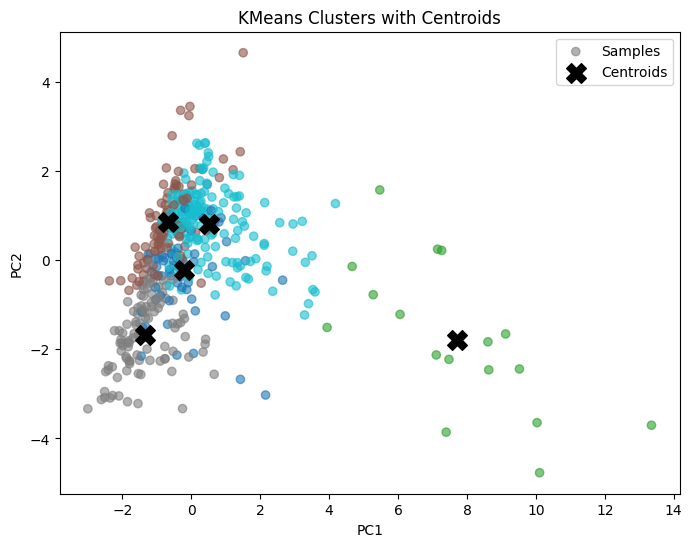

In [ ]:
kmeans_train = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans_train.fit_predict(X_scaled_kmeans)
centers_ndim = kmeans_train.cluster_centers_
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled_kmeans)
centers_2d = pca.transform(centers_ndim)
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_kmeans, cmap='tab10', alpha=0.6, label='Samples')
plt.scatter(centers_2d[:,0], centers_2d[:,1], marker='X', s=200, c='black', label='Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters with Centroids')
plt.legend()
plt.show()

In [ ]:
km_train.inertia_

2044.7688386138484

In [ ]:
distances_train = np.linalg.norm(
    X_scaled_kmeans[:, np.newaxis, :] - centers_ndim,
    axis=2
)
nearest_centroid_dist_train = distances_train.min(axis=1).reshape(-1, 1)
train_feature_engineered["dist_to_nearest_centroid"] = nearest_centroid_dist_train
X["dist_to_nearest_centroid"] = nearest_centroid_dist_train

Test Data

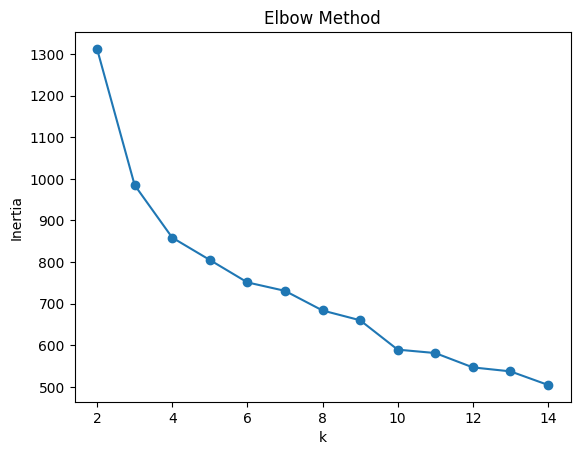

In [ ]:
inertias = []
for k in range(2, 15):
    km_test = KMeans(n_clusters=k, random_state=42)
    km_test.fit(X_test_scaled_kmeans)
    inertias.append(km_test.inertia_)
plt.plot(range(2, 15), inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

For test data, k=4 seems to be the right choice.

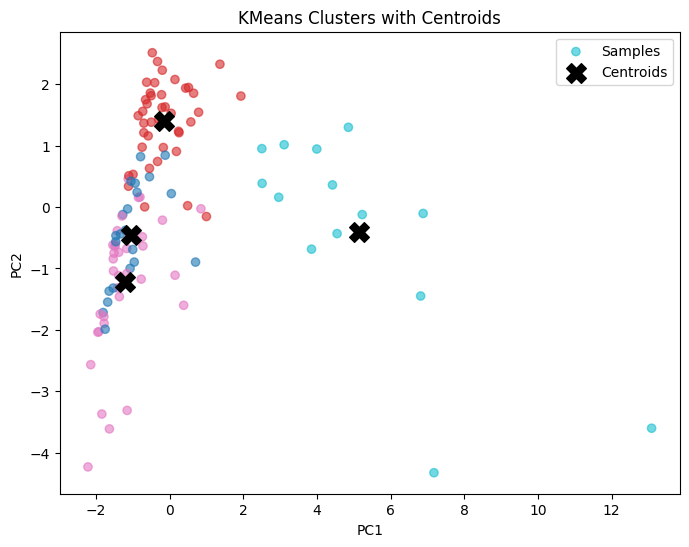

In [ ]:
kmeans_test = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans_test.fit_predict(X_test_scaled_kmeans)
centers_ndim = kmeans_test.cluster_centers_
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_test_scaled_kmeans)
centers_2d = pca.transform(centers_ndim)
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_kmeans, cmap='tab10', alpha=0.6, label='Samples')
plt.scatter(centers_2d[:,0], centers_2d[:,1], marker='X', s=200, c='black', label='Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters with Centroids')
plt.legend()
plt.show()

In [ ]:
distances_test = np.linalg.norm(
    X_test_scaled_kmeans[:, np.newaxis, :] - centers_ndim, axis=2)
nearest_centroid_dist_test = distances_test.min(axis=1).reshape(-1, 1)
test_feature_engineered["dist_to_nearest_centroid"] = nearest_centroid_dist_test
X_test["dist_to_nearest_centroid"] = nearest_centroid_dist_test

### Feature importance
We use a random forest classifier to measure each features relative importance. We can then determine how well our enginered features perform and potentially drop low value features which should reduce noise and improve generalisation

In [ ]:
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
rnd_clf.fit(X, y)
y_pred_rf = rnd_clf.predict(X_test)
rnd_clf.feature_importances_
feat_importances = pd.DataFrame({ 'feature': X.columns
                                 ,'importance': rnd_clf.feature_importances_})
feat_importances = feat_importances.sort_values(by='importance', ascending=False).reset_index(drop=True)
print(feat_importances)

                     feature  importance
0                       year    0.106824
1                   song_age    0.106480
2                        dur    0.082308
3                    log_dur    0.078705
4               energy_dance    0.076247
5                       nrgy    0.070313
6                      beats    0.064340
7                        pop    0.063090
8                      acous    0.060517
9                  title_ftr    0.052595
10                      dnce    0.041771
11                       bpm    0.036920
12  dist_to_nearest_centroid    0.032467
13                       val    0.029070
14              loudness_pos    0.025385
15                      live    0.025307
16                        dB    0.025239
17                      spch    0.022422


We can see from the above importances that the newly engineered features have more importance than the raw features (already present in dataset), hence giving the model more information-rich features for classifying.

In [ ]:
# removing some of the original or less important features after FE
train_feature_engineered.drop(columns=['live','spch','dB'], inplace=True)
test_feature_engineered.drop(columns=['live','spch','dB'], inplace=True)

### Processing pipeline
The final part of pre processing is done using ColumnTransformer, which handles our text and numeric columns seperatly and is all wrapped in a single pipeline.

In [ ]:
# checking for NA values
train_feature_engineered["title"] = train_feature_engineered["title"].fillna("")
train_feature_engineered["artist"] = train_feature_engineered["artist"].fillna("")
test_feature_engineered["title"] = test_feature_engineered["title"].fillna("")
test_feature_engineered["artist"] = test_feature_engineered["artist"].fillna("")
target = "top genre"
text_cols = ["artist"]
num_cols = [c for c in train_feature_engineered.columns if c not in ["Id", target, "title", "artist"]]
X_all = train_feature_engineered[text_cols + num_cols]
y_all = train_feature_engineered[target]
X_test_all = test_feature_engineered[text_cols + num_cols]
class_counts = y_all.value_counts()
mask_split = y_all.map(class_counts) >= 2
X_split = X_all.loc[mask_split].copy()
y_split = y_all.loc[mask_split].copy()
X_tr, X_val, y_tr, y_val = train_test_split(X_split, y_split, test_size=0.2,
                                            random_state=42, stratify=y_split)
preprocess = ColumnTransformer(
    transformers=[
        ("artist_tfidf", TfidfVectorizer(max_features=20, ngram_range=(1, 2),
                                         min_df=1, sublinear_tf=True), "artist"),  # to capture information from textual featurs
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")), # to impute missing data using median as basis to remidtae effect of any skewness in data. also samples dropping missing values is not a good option considering the amount of data we have
            ("power", PowerTransformer(method="yeo-johnson", standardize = False)), #to make the data more Gaussian-like in order to stabilize variance and minimize skewness
            ("scaler", RobustScaler()) #robust scaler as it's more robust to outliers as compared to Standard or other scalers
        ]), num_cols)
    ],
    remainder="drop",
    sparse_threshold=0.3
)


**Models tried:**
LinearSVC; LogisticRegression; RandomForestClassifier; AdaBoostClassifier


**Hyperparametrs Tuning**

To calculate the best parameters, we used the library GridSearchCV. This works by taking a grid of hyperparameters, training and testing the model on every combination of those hyperparameters and giving us the best combination.

In [ ]:
model = LinearSVC(C=0.8, max_iter=10000)
clf_text = Pipeline(steps=[("prep", preprocess), ("model", model)])
clf_text.fit(X_tr, y_tr)
val_pred = clf_text.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, val_pred))

Validation accuracy: 0.525


**Performance**

The training dataset provided for the problem was split into 80-20 train-validation split. The accuracy for each model on validation split was:

1.   Linear SVC: 52.8%
2.   Logistic Regression: 50%
3.   Random Forest: 45%
4.   Adaboost: 48.75%




**Observation**

Experimented with Multiple models. However, simple models like linearSVC tends to perform better. This is likely due to the limited dataset size, which caused higher-capacity models to overfit, whereas linear models generalized more effectively.


In [ ]:
test_pred = clf_text.predict(X_test_all)
submission = pd.DataFrame({"Id": classification_test_df["Id"],
                           "top genre": test_pred})
submission.to_csv("spotify_predictions_lr.csv", index=False)


**Kaggle Performance**

The predictions generated above, when uploaded to kaggle, got an accuracy score of 51.78% on the leaderboard (Group 15). This score is almost identical to the one obtained on the validation split by our best fit model i.e. Linear SVC. A small difference between accuracy on validation data and leaderboard performance i.e. evaluated on test dataset (~0.72%) likely arises from data split variance and minor distributional differences between both datasets.

## Regression



In [ ]:
train_df = pd.read_csv("/content/CS98XRegressionTrain.csv")
test_df = pd.read_csv("/content/CS98XRegressionTrain.csv")

### EDA

#### Distribution of Popularity

Understanding the distribution of the target is important because it informs us whether or not transformation is necessary and it shows any skew or outliers

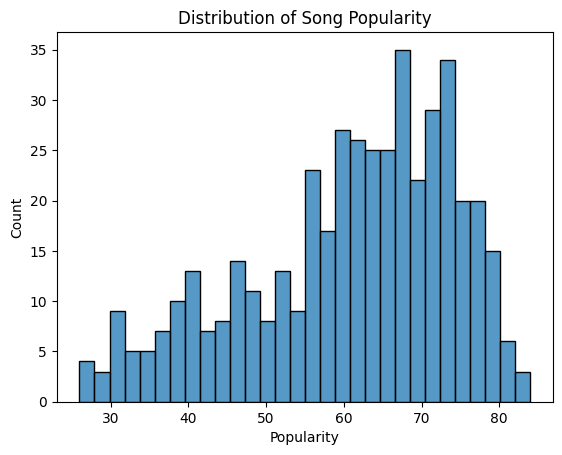

In [ ]:
sns.histplot(train_df["pop"], bins=30)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

Popularity score is approximately normally distributed. Most songs are within the 55-75 range. No severe skewness or extreme outliers appear (no transformations are needed).

#### Feature Correlation Analysis
Here we examine the correlations between features to:
- Identify multicollinearity.
- Identify strong linear relationships between features
- Understand any potential redundancy between variables.

High multicollinearity may affect linear models but would have less impact on tree based methods.

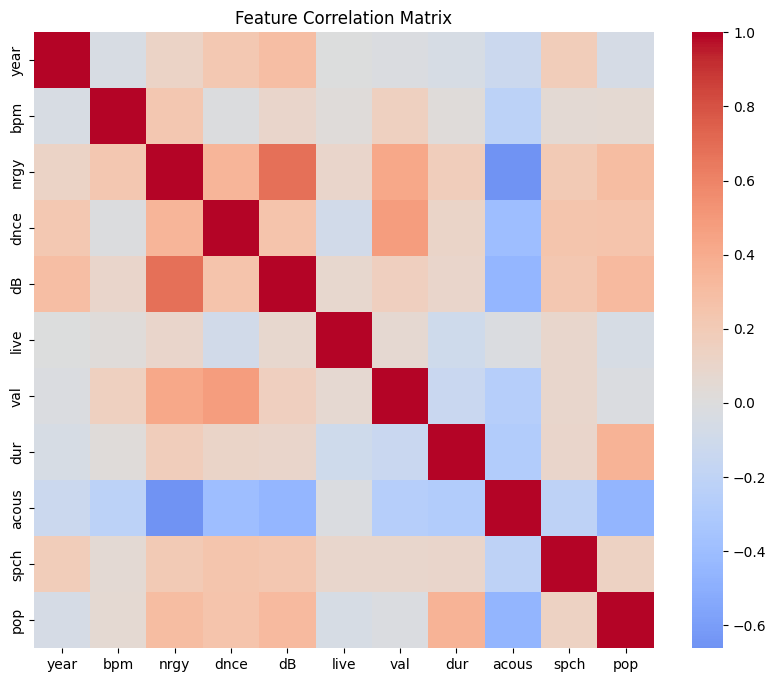

In [ ]:
corr_df = train_df.drop(columns=["Id"]).select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

No single feature shows a strong linear relationship with popularity.

#### Feature-popularity scatter plot comparison

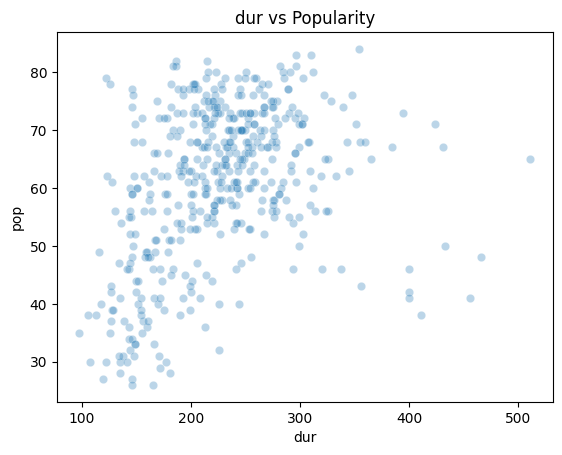

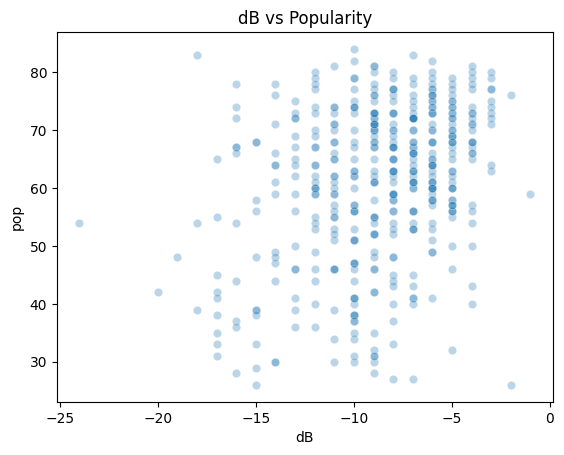

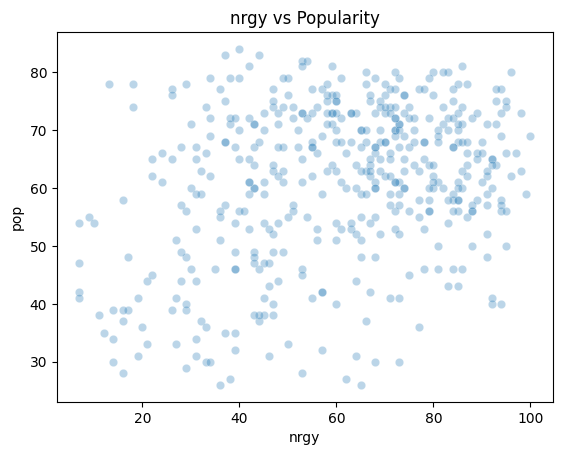

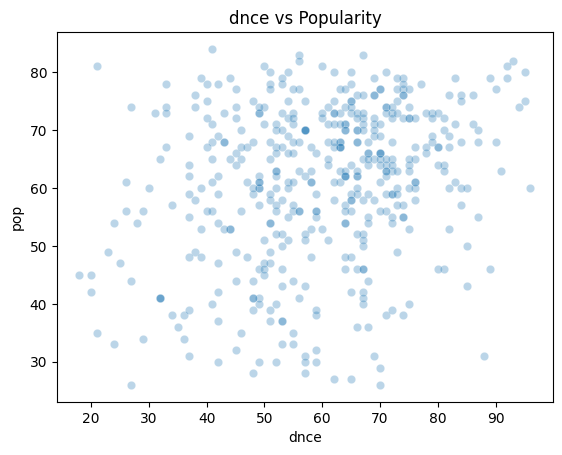

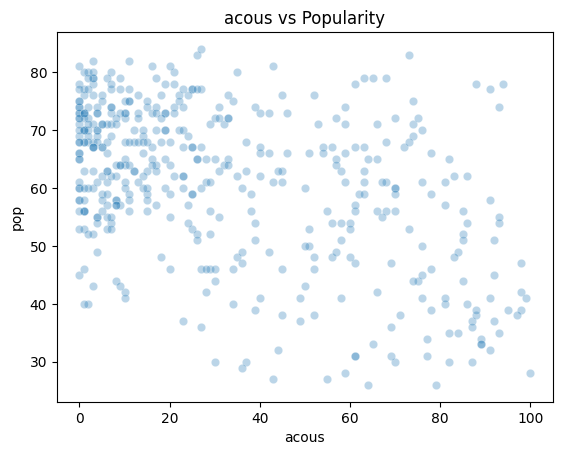

In [ ]:
features = ["dur", "dB", "nrgy", "dnce", "acous"]
for f in features:
    sns.scatterplot(x=train_df[f], y=train_df["pop"], alpha=0.3)
    plt.title(f"{f} vs Popularity")
    plt.show()

We can see that the relationships appear scattered and non-linear. Although we can see some structure, a large variance remains unexplained.

### Preprocessing and Feature Engineering
We saw that the dataset primarily contains structured numeric audio features.

#### Handling Missing Values

Missing values in the `top genre` column were replaced with the category `"Unknown"`.

Dropping rows would unnecessarily reduce training data, a separate category preserves information while avoiding bias.

In [ ]:
train_df["top genre"] = train_df["top genre"].fillna("Unknown")
test_df["top genre"] = test_df["top genre"].fillna("Unknown")
train_df["top genre"].value_counts().head(20).sum() / len(train_df)

np.float64(0.7660044150110376)

#### Reducing Genre Cardinality
The 'top genre' column originally contained 86 unique categories, many of which only appeared only a few times. To address this, only the 20 most frequent genres were retained and all others grouped into an 'Other' category. 20 was chosen specifically as 20 genres account for 74.4% of the dataset as shown below. Including all 86 categories would have produced highly sparse dummy variables and increased the risk of overfitting to rare genres.

In [ ]:
top_genres = train_df["top genre"].value_counts().nlargest(20).index
train_df["top genre"] = train_df["top genre"].where(
    train_df["top genre"].isin(top_genres), "Other")
test_df["top genre"] = test_df["top genre"].where(
    test_df["top genre"].isin(top_genres),
    "Other")

#### Dropping columns
The 'title' and 'artist' columns were removed as both variables contain a large number of unique values. Encoding these would significanty increase dimentionslity and could lead to overfitting (many artists appear only a small number of times). Further, the models could memorise specific artists associated with high popularity rather than learning audio patterns. Since the goal is to predict based on characteristics and not memorise identities, we removed these columns.

In [ ]:
y = train_df["pop"] # target
X = train_df.drop(columns=["Id", "pop", "title", "artist"])
X_test = test_df.drop(columns=["Id", "title", "artist"])

#### One-Hot Encoding
The 'top genre' column was one-hot encoded. This allows the model to treat the genres independently and works wel with tree-based models.
- `drop_first=True` was used to reduce redundancy and multicollinearity for linear models.

In [ ]:
X = pd.get_dummies(X, columns=["top genre"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["top genre"], drop_first=True)

#### Interaction Features
Interaction terms were created to let linear models capture limited non-linear relationships and to provide additional structured information to ensemble models.

In [ ]:
X["nrgy_dB"] = X["nrgy"] * X["dB"]
X["nrgy_dnce"] = X["nrgy"] * X["dnce"]
X["dnce_val"] = X["dnce"] * X["val"]
X["dur_nrgy"] = X["dur"] * X["nrgy"]
X["acous_val"] = X["acous"] * X["val"]
X_test["nrgy_dB"] = X_test["nrgy"] * X_test["dB"]
X_test["nrgy_dnce"] = X_test["nrgy"] * X_test["dnce"]
X_test["dnce_val"] = X_test["dnce"] * X_test["val"]
X_test["dur_nrgy"] = X_test["dur"] * X_test["nrgy"]
X_test["acous_val"] = X_test["acous"] * X_test["val"]
X.head()

,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,...,top genre_disco,top genre_eurodance,top genre_europop,top genre_glam rock,top genre_pop,nrgy_dB,nrgy_dnce,dnce_val,dur_nrgy,acous_val
0,1996,107,31,45,-8,13,28,150,75,3,...,False,False,False,False,False,-248,1395,1260,4650,2100
1,2011,114,44,53,-8,13,47,139,49,3,...,False,False,False,False,False,-352,2332,2491,6116,2303
2,1979,105,36,63,-9,13,67,245,11,3,...,False,False,False,False,False,-324,2268,4221,8820,737
3,1980,170,28,47,-16,13,33,232,25,3,...,False,False,False,False,False,-448,1316,1551,6496,825
4,1973,121,47,56,-8,15,40,193,45,3,...,False,False,False,True,False,-376,2632,2240,9071,1800


A new feature, 'year_since_2000', was created below to represent recency relative to the year 2000. Relative time is more informative than absolute year values. It also improves numerical stability.

In [ ]:
X["year_since_2000"] = X["year"] - 2000
X_test["year_since_2000"] = X_test["year"] - 2000

#### Train-Test Alignment
After both encoding and feature engineering, the test dataset was reindexed to match the training feature matrix. This is to make sure feature ordering is identical and prevents prediction errors.

In [ ]:
X_test = X_test.reindex(columns=X.columns, fill_value=0)

### 4. Models (RMSE with 5-fold CV)

#### Linear Regression (Baseline Model)

Linear regression is used as a baseline model; it is good to compare with more complex models. Scaling is applied to prevent data leakage during cross-validation.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lr = LinearRegression()
rmse_lr = -cross_val_score(lr, X_scaled, y,
                           scoring="neg_root_mean_squared_error", cv=5).mean()
print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 10.661930694329715


Linear Regression achieved an RMSE of: 10.66 which establishes a baseline for comparison. The performance suggests that purely linear relationships may not capture the structure of the data fully.

#### Decision Tree Regressor

Decision Trres are introduced to capture non-linear relationships.


In [ ]:
dt = DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_leaf=5)
rmse_dt = -cross_val_score(dt, X, y
, scoring="neg_root_mean_squared_error", cv=5).mean()
print("Decision Tree Regressor RMSE:", rmse_dt)

Decision Tree Regressor RMSE: 12.098901016790924


The Decision Tree achieved an RMSE of 12.1 which is a lot worse the Linear Regression baseline (10.66). It suggests that this model is prone to overfitting and poor generalisation, as single trees are susceptible to high variance. Despite the fact that decision trees can capture non-linear relationships, a single tree lacks the stability of ensemble methods.

- Given this weaker performance, further hyperparameter tuning wasn't prioritised, as ensemble methods are known to be more effective for structured data.

#### Random Forest
Random Forest reduces variance by averaging multiple decision trees, improving stability and generalisation compared to a single tree (as seen above). Hyperparameter tuning using RandomizedSearchCV was applied because the model contains structural parameters (e.g., number of trees, maximum depth etc). Optimising these values can significantly improve performance.
- It works by randomly sampling a fixed number of parameter combinations from defined distributions.

In [ ]:
rf = RandomForestRegressor(n_estimators=500, max_depth=10, min_samples_leaf=2,
    max_features=0.6, random_state=42,)
rmse_rf = -cross_val_score(rf, X, y,
                           scoring="neg_root_mean_squared_error", cv=5).mean()
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 10.487855930884649


The tuned Random Forest achieved an RMSE of 10.49. Although the improvement over Linear Regression is ever so slight, it underscores that ensemble methods provide more stable predictions than individual trees.

#### Gradient Boosting


In [ ]:
gbr = GradientBoostingRegressor(
    n_estimators=800, learning_rate=0.005, max_depth=4, subsample=0.8,
    random_state=42, min_samples_split=2, min_samples_leaf=8,
    max_features='sqrt', loss='squared_error'
)
rmse_gbr = -cross_val_score(gbr, X, y, scoring="neg_root_mean_squared_error",
    cv=5).mean()
print("Gradient Boosting RMSE:", rmse_gbr)

Gradient Boosting RMSE: 10.218752828506203


The Gradient Boosting model achieved an RMSE of 10.218 which is the lowest amongst all models tested. This shows that it successfully captured residual structure that wasnt fully recognised by Random Forest.

### Comparison of all models RMSE

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"
                , "Gradient Boosting"],
    "CV RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_gbr]
})
results.sort_values("CV RMSE")

,Model,CV RMSE
3,Gradient Boosting,10.218753
2,Random Forest,10.487856
0,Linear Regression,10.661931
1,Decision Tree,12.098901


Gradient Boosting achieved the lowest cross-validation RMSE, followed by Random Forest and Linear Regression. The Decision Tree performed worst, likely due to high variance. This progression confirms that ensemble methods improve generalisation for this dataset.

### 5. Train Final Model and create submission csv
The tuned Gradient Boosting Regressor was retrained on the full dataset before generating test predictions.

In [ ]:
# Train on full training data for Gradient Boosting
submission_model = gbr
submission_model.fit(X, y)
test_preds = submission_model.predict(X_test)
# create submissimon
submission = pd.DataFrame({"Id": test_df["Id"], "pop": test_preds})
submission.head()

,Id,pop
0,1,48.655054
1,2,36.613909
2,3,67.426067
3,4,63.847088
4,5,63.474700


### Cross-Validation vs Kaggle Performance
The tuned Gradient Boosting model achieved a mean 5-fold cross-validation RMSE of 10.218.
On the Kaggle public leaderboard, the model achieved an RMSE of 7.08.
This difference may be due to the distributional differences between the validation folds and the hidden test set, as well as the impact of retraining the final model on the full training dataset. What's important to note here is that improvements observed during cross-validation were reflected in our performance on the leaderboard.Although ensemble methods improved performance, the differences between the strongest models were quite small.